# Compare Diffusion U-Net Refinement With Phase-1 Inference

This notebook compares the recent diffusion-U-Net refined ensemble mean with its matching deterministic Phase-1 inference over the configured PRISM grid.

Both products come from the same daily `diffusion_unet_refined_YYYYMMDD.nc` file: `<variable>` is the refined ensemble mean and `<variable>_phase1` is the FP32 Phase-1 baseline used by that run. This preserves the same dates, grid, checkpoint provenance, and valid-pixel support.

Climatology maps show both phases with shared color limits. Metrics and LA County/City GIFs show **refined minus Phase 1**. Raw PRISM observations and the older standalone Phase-1 output files are not needed.


In [1]:
from pathlib import Path
import hashlib
import json
import re
import sys

import numpy as np
import pandas as pd
import xarray as xr
import yaml

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from dask.distributed import Client, LocalCluster

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    CARTOPY_AVAILABLE = True
except ImportError:
    ccrs = None
    cfeature = None
    CARTOPY_AVAILABLE = False

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "granitewxc").exists():
    REPO_ROOT = REPO_ROOT.parent
for import_root in (REPO_ROOT, REPO_ROOT / "examples" / "NARR_PRISM"):
    if str(import_root) not in sys.path:
        sys.path.insert(0, str(import_root))

from narr_prism_utils import case_output_dir, get_case_name, resolve_path
from granitewxc.refinement import resolve_refinement_config
from granitewxc.utils.config import get_config
from granitewxc.utils.prism_evaluation import validate_evaluation_coordinates
from granitewxc.utils.prism_grid import load_canonical_grid

print(f"Repository root: {REPO_ROOT}")
print(f"Cartopy available: {CARTOPY_AVAILABLE}")

Repository root: /data/granite-wxc
Cartopy available: True


## User Parameters

In [2]:
# ===================== USER PARAMETERS (EDIT ME) =====================
CONFIG_PATH = REPO_ROOT / "examples" / "NARR_PRISM" / "NARR_PRISM_diffusion_unet.yaml"

# None uses the YAML output directory plus refinement_diffusion_unet.
INFERENCE_OUTPUT_ROOT = None

# Climatology period. None means use the YAML inference period, clipped to files found.
MAKE_CLIMATOLOGY = True  # Skip all climatology work when regenerating only the GIF.
# For faster first runs, set a smaller range such as "2016-01-01" to "2016-12-31".
CLIMO_START = None
CLIMO_END = None
CLIMO_DATE_STEP = 1  # Exact daily climatology. Use 7 or 30 for a faster sampled preview.
USE_DASK_CLIMATOLOGY = True
CLIMO_DASK_WORKERS = 4  # Separate processes avoid NetCDF/HDF5 thread-lock contention.
CLIMO_DASK_BATCH_DAYS = 8  # Bounds memory while workers read days concurrently.
FORCE_RECOMPUTE_CLIMO = False  # Reuse the saved NetCDF climatology when available.

# Each GIF frame reads the refined mean and Phase-1 baseline from one file.
GIF_START = "2016-08-01"
GIF_END = "2016-08-31"
GIF_FPS = 2
GIF_VARIABLE = "tmax"
MAKE_LA_COUNTY_GIF = True
# Bounding box that contains LA County.
LA_COUNTY_BOUNDS = {"lon_min": -118.95, "lon_max": -117.64, "lat_min": 33.70, "lat_max": 34.82}

# A tighter City of Los Angeles view, including downtown and the harbor.
MAKE_LA_CITY_GIF = True
LA_CITY_GIF_START = "2025-07-01"
LA_CITY_GIF_END = "2025-07-31"
LA_CITY_BOUNDS = {"lon_min": -118.67, "lon_max": -118.15, "lat_min": 33.70, "lat_max": 34.34}

OUTPUT_DIR = REPO_ROOT / "examples" / "NARR_PRISM" / "experiments" / "comparison_plots" / "diffusion_unet_vs_phase1"
MAKE_GIFS = True

# Map backgrounds use Cartopy PlateCarree when available.
USE_CARTOPY = True
SHOW_COUNTIES = False  # County boundaries can trigger a Natural Earth download.
MAP_FEATURE_SCALE = "10m"  # "10m", "50m", or "110m"
COUNTY_FEATURE_SCALE = "10m"
ANIMATION_FEATURE_SCALE = "10m"  # Highest-resolution Natural Earth coastline.
ANIMATION_SHOW_COUNTIES = True
ANIMATION_COASTLINE_LINEWIDTH = 1.0
ANIMATION_COUNTY_LINEWIDTH = 0.45
# ====================================================================

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Comparison artifacts will be written to: {OUTPUT_DIR}")

Comparison artifacts will be written to: /data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/diffusion_unet_vs_phase1


## Load Configuration

In [3]:
with open(CONFIG_PATH, "r", encoding="utf-8") as fh:
    cfg = yaml.safe_load(fh)

data_cfg = cfg["data"]
case_name = get_case_name(cfg)
target_variables = list(data_cfg.get("target_variables", ["ppt", "tmax", "tmin"]))
spatial_subset = data_cfg.get("spatial_subset", {}) or {}

refinement = resolve_refinement_config(get_config(str(CONFIG_PATH)))
refinement_type = refinement.type
if not refinement.is_active or refinement_type != "diffusion_unet":
    raise ValueError(
        f"{CONFIG_PATH} must enable model.refinement.type=diffusion_unet; "
        f"resolved type={refinement_type!r}, active={refinement.is_active}"
    )

if INFERENCE_OUTPUT_ROOT is not None:
    inference_root = resolve_path(INFERENCE_OUTPUT_ROOT)
else:
    base_inference_root = resolve_path(
        cfg.get("inference", {}).get(
            "refinement_output_dir",
            cfg.get("inference", {}).get(
                "output_dir",
                "./examples/NARR_PRISM/experiments/inference_output",
            ),
        )
    )
    inference_root = base_inference_root / f"refinement_{refinement_type}"
inference_dir = case_output_dir(inference_root, case_name)
preprocessed_case_dir = case_output_dir(resolve_path(data_cfg["preprocessed_dir"]), case_name)
canonical_grid = load_canonical_grid(preprocessed_case_dir)
comparison_reference = "embedded_phase1"

yaml_start = pd.Timestamp(cfg["dates"]["inference"]["start"])
yaml_end = pd.Timestamp(cfg["dates"]["inference"]["end"])

print(f"Config: {CONFIG_PATH}")
print(f"Case name: {case_name}")
print(f"Variables: {target_variables}")
print(f"Refinement type: {refinement_type}")
print(f"Inference dir: {inference_dir}")
print("Comparison: refined ensemble mean versus matching <variable>_phase1 fields")
print(f"Canonical PRISM grid: {canonical_grid.shape} ({canonical_grid.fingerprint[:12]})")
print(f"YAML inference period: {yaml_start.date()} to {yaml_end.date()}")
print(f"Spatial subset: {spatial_subset}")


Config: /data/granite-wxc/examples/NARR_PRISM/NARR_PRISM_diffusion_unet.yaml
Case name: narr_prism_California
Variables: ['ppt', 'tmax', 'tmin']
Refinement type: diffusion_unet
Inference dir: /data2/granite-wxc-artifacts/NARR_PRISM/experiments/inference_output/refinement_diffusion_unet/narr_prism_California
Comparison: refined ensemble mean versus matching <variable>_phase1 fields
Canonical PRISM grid: (1024, 1024) (f062e76bd115)
YAML inference period: 2016-01-01 to 2025-12-31
Spatial subset: {'enabled': True, 'lat_min': 32.55, 'lat_max': 41.075, 'lon_min': -124.45, 'lon_max': -115.925}


## Helper Functions

In [4]:
DATE_RE = re.compile(r"_(\d{8})\.nc$")

VAR_LABELS = {
    "ppt": "Precipitation",
    "tmax": "Maximum temperature",
    "tmin": "Minimum temperature",
}
VAR_UNITS = {"ppt": "mm/day", "tmax": "deg C", "tmin": "deg C"}
VAR_CMAPS = {"ppt": "viridis", "tmax": "magma", "tmin": "plasma"}


def inference_file(date):
    token = pd.Timestamp(date).strftime("%Y%m%d")
    return inference_dir / f"{case_name}_{refinement_type}_refined_{token}.nc"


def dates_from_inference_files():
    dates = []
    for path in sorted(inference_dir.glob(f"{case_name}_{refinement_type}_refined_*.nc")):
        match = DATE_RE.search(path.name)
        if match:
            dates.append(pd.Timestamp(match.group(1)))
    return pd.DatetimeIndex(dates)


def open_inference_day(date, variables=None):
    """Load a matched refined/Phase-1 pair and close its source file."""
    path = inference_file(date)
    variables = target_variables if variables is None else list(variables)
    names = variables + [f"{var}_phase1" for var in variables]
    with xr.open_dataset(path) as ds:
        if ds.attrs.get("refinement_type") != refinement_type:
            raise ValueError(f"{path}: expected refinement_type={refinement_type!r}")
        validate_evaluation_coordinates(canonical_grid.lat, ds.lat.values, name="latitude", context=str(path))
        validate_evaluation_coordinates(canonical_grid.lon, ds.lon.values, name="longitude", context=str(path))
        if ds.sizes.get("time") != 1 or pd.Timestamp(ds.time.values[0]).normalize() != pd.Timestamp(date).normalize():
            raise ValueError(f"{path}: daily time coordinate does not match {date}")
        missing = [name for name in names if name not in ds.data_vars]
        if missing:
            raise KeyError(f"{path}: missing paired refined/Phase-1 variables {missing}")
        # Compare only products from the same run as the latest daily file.
        for key in ("phase1_fingerprint", "phase2_fingerprint", "phase1_cache_digest"):
            if ds.attrs.get(key) != inference_model_identity[key]:
                raise ValueError(f"{path}: {key} differs from the latest diffusion-U-Net output")
        return ds[names].load()


def date_range(start, end):
    return pd.date_range(pd.Timestamp(start), pd.Timestamp(end), freq="D")


def existing_common_dates(start, end, variables=None):
    # Both phases share one daily file. The loader validates requested fields.
    return pd.DatetimeIndex([
        date for date in date_range(start, end)
        if inference_file(date).is_file()
    ])


def symmetric_limits(da, q=0.98):
    vals = np.asarray(da.values).ravel()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return -1.0, 1.0
    lim = float(np.nanquantile(np.abs(vals), q))
    if not np.isfinite(lim) or lim == 0:
        lim = 1.0
    return -lim, lim


def field_limits(*arrays, q=0.02):
    vals = np.concatenate([np.asarray(a.values).ravel() for a in arrays])
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return 0.0, 1.0
    lo = float(np.nanquantile(vals, q))
    hi = float(np.nanquantile(vals, 1 - q))
    if lo == hi:
        hi = lo + 1.0
    return lo, hi


def cartopy_enabled():
    return bool(USE_CARTOPY and CARTOPY_AVAILABLE)


def map_subplot_kw():
    return {"projection": ccrs.PlateCarree()} if cartopy_enabled() else {}


def map_plot_kwargs():
    return {"transform": ccrs.PlateCarree()} if cartopy_enabled() else {}


def map_extent(da, pad_fraction=0.02):
    lon0 = float(da.lon.min())
    lon1 = float(da.lon.max())
    lat0 = float(da.lat.min())
    lat1 = float(da.lat.max())
    lon_pad = max((lon1 - lon0) * pad_fraction, 0.01)
    lat_pad = max((lat1 - lat0) * pad_fraction, 0.01)
    return [lon0 - lon_pad, lon1 + lon_pad, lat0 - lat_pad, lat1 + lat_pad]


def add_map_background(
    ax,
    da,
    *,
    show_counties=None,
    feature_scale=None,
    coastline_linewidth=0.7,
    county_linewidth=0.25,
):
    if not cartopy_enabled():
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        return

    show_counties = SHOW_COUNTIES if show_counties is None else show_counties
    feature_scale = MAP_FEATURE_SCALE if feature_scale is None else feature_scale
    data_crs = ccrs.PlateCarree()
    ax.set_extent(map_extent(da), crs=data_crs)
    ax.coastlines(resolution=feature_scale, linewidth=coastline_linewidth, color="0.08", zorder=5)
    ax.add_feature(cfeature.BORDERS.with_scale(feature_scale), linewidth=0.5, edgecolor="0.25", zorder=5)
    ax.add_feature(cfeature.STATES.with_scale(feature_scale), linewidth=0.65, edgecolor="0.15", zorder=5)
    if show_counties:
        counties = cfeature.NaturalEarthFeature(
            "cultural",
            "admin_2_counties",
            COUNTY_FEATURE_SCALE,
            facecolor="none",
        )
        ax.add_feature(counties, linewidth=county_linewidth, edgecolor="0.25", zorder=6)
    gl = ax.gridlines(draw_labels=True, linewidth=0.25, color="0.45", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}

## Discover Available Dates

In [5]:
inference_dates = dates_from_inference_files()
if len(inference_dates) == 0:
    raise FileNotFoundError(f"No inference files found in {inference_dir}")

print(f"Inference files: {len(inference_dates)} ({inference_dates.min().date()} to {inference_dates.max().date()})")

latest_inference_path = max(
    (inference_file(date) for date in inference_dates),
    key=lambda path: path.stat().st_mtime_ns,
)
with xr.open_dataset(latest_inference_path) as identity_ds:
    inference_model_identity = {
        key: str(identity_ds.attrs.get(key, ""))
        for key in ("checkpoint", "phase1_checkpoint", "phase2_checkpoint",
                    "phase1_fingerprint", "phase2_fingerprint", "phase1_cache_digest",
                    "refinement_type", "config_fingerprint")
    }
print(f"Latest output: {latest_inference_path.name}")
print(f"Output modified (UTC): {pd.Timestamp(latest_inference_path.stat().st_mtime, unit='s', tz='UTC')}")
print(f"Phase-1 checkpoint: {inference_model_identity['phase1_checkpoint']}")
print(f"Phase-2 checkpoint: {inference_model_identity['phase2_checkpoint']}")
# Check the latest paired product even when climatology is disabled.
latest_date = pd.Timestamp(DATE_RE.search(latest_inference_path.name).group(1))
with open_inference_day(latest_date) as latest_pair:
    print(f"Paired fields: {list(latest_pair.data_vars)}")

if MAKE_CLIMATOLOGY:
    climo_start = pd.Timestamp(CLIMO_START) if CLIMO_START else max(yaml_start, inference_dates.min())
    climo_end = pd.Timestamp(CLIMO_END) if CLIMO_END else min(yaml_end, inference_dates.max())
    if not isinstance(CLIMO_DATE_STEP, int) or CLIMO_DATE_STEP < 1:
        raise ValueError("CLIMO_DATE_STEP must be a positive integer")
    common_dates = existing_common_dates(climo_start, climo_end)[::CLIMO_DATE_STEP]

    if len(common_dates) == 0:
        raise FileNotFoundError(f"No paired refined/Phase-1 dates found between {climo_start.date()} and {climo_end.date()}")

    common_dates_hash = hashlib.sha256(common_dates.asi8.tobytes()).hexdigest()
    inference_source_digest = hashlib.sha256()
    for source_path in (inference_file(date) for date in common_dates):
        stat = source_path.stat()
        inference_source_digest.update(str(source_path.resolve()).encode())
        inference_source_digest.update(f"{stat.st_size}:{stat.st_mtime_ns}".encode())
    inference_source_digest.update(comparison_reference.encode())
    inference_source_digest.update(json.dumps(inference_model_identity, sort_keys=True).encode())
    inference_source_hash = inference_source_digest.hexdigest()
    climo_path = OUTPUT_DIR / (
        f"{case_name}_diffusion_unet_vs_phase1_climatology_{common_dates.min():%Y%m%d}_{common_dates.max():%Y%m%d}_"
        f"{inference_source_hash[:12]}.nc"
    )

    print(f"Climatology dates: {len(common_dates)} ({common_dates.min().date()} to {common_dates.max().date()}, step={CLIMO_DATE_STEP})")
    print(f"Climatology NetCDF: {climo_path}")
    sample = open_inference_day(common_dates[0])
    print(sample)
    sample.close()
else:
    common_dates = pd.DatetimeIndex([])
    climo_path = None
    print("Skipped climatology discovery (MAKE_CLIMATOLOGY=False).")

Inference files: 3653 (2016-01-01 to 2025-12-31)
Latest output: narr_prism_California_diffusion_unet_refined_20251231.nc
Output modified (UTC): 2026-09-15 16:17:03.184565783+00:00
Phase-1 checkpoint: /data2/granite-wxc-artifacts/NARR_PRISM/experiments/checkpoints/narr_prism_California/last.ckpt
Phase-2 checkpoint: /data2/granite-wxc-artifacts/NARR_PRISM/experiments/refinement_checkpoints/diffusion_unet/last.ckpt
Paired fields: ['ppt', 'tmax', 'tmin', 'ppt_phase1', 'tmax_phase1', 'tmin_phase1']
Climatology dates: 3653 (2016-01-01 to 2025-12-31, step=1)
Climatology NetCDF: /data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/diffusion_unet_vs_phase1/narr_prism_California_diffusion_unet_vs_phase1_climatology_20160101_20251231_aafe97fa5364.nc
<xarray.Dataset> Size: 25MB
Dimensions:      (time: 1, lat: 1024, lon: 1024)
Coordinates:
  * time         (time) datetime64[ns] 8B 2016-01-01
  * lat          (lat) float64 8kB 32.55 32.56 32.57 32.58 ... 41.06 41.07 41.08
  * lon      

## Compute Climatology Maps

Each task opens one refined inference file, loads its refined means and matching Phase-1 fields, and closes the file. Dask worker processes read a bounded batch of days; the main process accumulates float64 sums and per-pixel counts on the intersection of finite pixels from both phases.

The mean difference and root-mean-square (RMS) difference both use **refined minus Phase 1**. These quantify the changes introduced by refinement. Set `USE_DASK_CLIMATOLOGY = False` for sequential processing. Cached climatologies include the comparison reference, date selection, and source-file identity, so changing the products invalidates the cache.


In [6]:
CLIMO_FIELD_NAMES = ("inference", "phase1", "difference", "rms_difference", "count")


def climo_var_name(var, field):
    return f"{var}_{field}"


def climo_from_dataset(ds):
    return {
        var: {field: ds[climo_var_name(var, field)] for field in CLIMO_FIELD_NAMES}
        for var in target_variables
    }


def climo_cache_matches(path):
    if not path.exists():
        return False
    required = {
        climo_var_name(var, field)
        for var in target_variables
        for field in CLIMO_FIELD_NAMES
    }
    try:
        with xr.open_dataset(path) as cached:
            return (
                required.issubset(cached.data_vars)
                and cached.attrs.get("case_name") == case_name
                and cached.attrs.get("comparison_reference") == comparison_reference
                and cached.attrs.get("grid_fingerprint") == canonical_grid.fingerprint
                and cached.attrs.get("start_date") == common_dates.min().strftime("%Y-%m-%d")
                and cached.attrs.get("end_date") == common_dates.max().strftime("%Y-%m-%d")
                and int(cached.attrs.get("date_count", -1)) == len(common_dates)
                and cached.attrs.get("dates_hash") == common_dates_hash
                and cached.attrs.get("inference_source_hash") == inference_source_hash
                and cached.attrs.get("inference_model_identity") == json.dumps(inference_model_identity, sort_keys=True)
                and np.array_equal(cached.lat.values, canonical_grid.lat)
                and np.array_equal(cached.lon.values, canonical_grid.lon)
            )
    except (OSError, ValueError, KeyError):
        return False


def finalize_mean(total, count):
    result = np.full(total.shape, np.nan, dtype=np.float64)
    np.divide(total, count, out=result, where=count > 0)
    return result.astype("float32")


def load_climatology_day(date):
    """Read only the paired fields; no observation or ensemble-member I/O."""
    with open_inference_day(date, variables=target_variables) as ds:
        return {
            var: (
                np.asarray(ds[var].isel(time=0).values, dtype="float32"),
                np.asarray(ds[f"{var}_phase1"].isel(time=0).values, dtype="float32"),
            )
            for var in target_variables
        }


def accumulate_climatology_day(accumulators, fields, difference):
    for var, (inf, baseline) in fields.items():
        valid = np.isfinite(inf)
        np.logical_and(valid, np.isfinite(baseline), out=valid)
        acc = accumulators[var]

        # Sum first and divide once at the end. Per-pixel counts preserve the
        # correct mean where either product contains missing values.
        np.add(acc["inference"], inf, out=acc["inference"], where=valid)
        np.add(acc["phase1"], baseline, out=acc["phase1"], where=valid)
        np.subtract(inf, baseline, out=difference)
        np.add(acc["difference"], difference, out=acc["difference"], where=valid)
        np.square(difference, out=difference)
        np.add(acc["sumsq"], difference, out=acc["sumsq"], where=valid)
        np.add(acc["count"], valid, out=acc["count"])


def stream_climatology_days(accumulators, dates, difference):
    for i, date in enumerate(dates, start=1):
        if i == 1 or i % 100 == 0 or i == len(dates):
            print(f"[{i:>5}/{len(dates)}] {date.date()}")
        accumulate_climatology_day(accumulators, load_climatology_day(date), difference)


def dask_climatology_days(accumulators, dates, difference):
    if not isinstance(CLIMO_DASK_WORKERS, int) or CLIMO_DASK_WORKERS < 1:
        raise ValueError("CLIMO_DASK_WORKERS must be a positive integer")
    if not isinstance(CLIMO_DASK_BATCH_DAYS, int) or CLIMO_DASK_BATCH_DAYS < 1:
        raise ValueError("CLIMO_DASK_BATCH_DAYS must be a positive integer")

    worker_count = min(CLIMO_DASK_WORKERS, len(dates))
    print(f"Dask climatology: {worker_count} processes, batches of {CLIMO_DASK_BATCH_DAYS} days")
    cluster = LocalCluster(
        n_workers=worker_count,
        threads_per_worker=1,
        processes=True,
        dashboard_address=None,
    )
    try:
        with Client(cluster) as client:
            for start in range(0, len(dates), CLIMO_DASK_BATCH_DAYS):
                batch = list(dates[start:start + CLIMO_DASK_BATCH_DAYS])
                futures = client.map(load_climatology_day, batch, pure=False)
                daily_fields = client.gather(futures)
                for fields in daily_fields:
                    accumulate_climatology_day(accumulators, fields, difference)
                completed = start + len(batch)
                print(f"[{completed:>5}/{len(dates)}] {batch[-1].date()}")
    finally:
        cluster.close()


if not MAKE_CLIMATOLOGY:
    climo_ds = None
    climo = None
    print("Skipped climatology calculation (MAKE_CLIMATOLOGY=False).")
elif not FORCE_RECOMPUTE_CLIMO and climo_cache_matches(climo_path):
    climo_ds = xr.load_dataset(climo_path)
    climo = climo_from_dataset(climo_ds)
    print(f"Loaded cached climatology: {climo_path}")
else:
    # NumPy ufuncs update these arrays in place. This avoids the repeated
    # xarray alignment and full-grid temporary allocations in the old loop.
    shape = canonical_grid.shape
    accumulators = {
        var: {
            "inference": np.zeros(shape, dtype="float64"),
            "phase1": np.zeros(shape, dtype="float64"),
            "difference": np.zeros(shape, dtype="float64"),
            "sumsq": np.zeros(shape, dtype="float64"),
            "count": np.zeros(shape, dtype="int32"),
        }
        for var in target_variables
    }
    difference = np.empty(shape, dtype="float32")

    if USE_DASK_CLIMATOLOGY and len(common_dates) > 1:
        dask_climatology_days(accumulators, common_dates, difference)
    else:
        stream_climatology_days(accumulators, common_dates, difference)

    data_vars = {}
    for var, acc in accumulators.items():
        data_vars[climo_var_name(var, "inference")] = (("lat", "lon"), finalize_mean(acc["inference"], acc["count"]))
        data_vars[climo_var_name(var, "phase1")] = (("lat", "lon"), finalize_mean(acc["phase1"], acc["count"]))
        data_vars[climo_var_name(var, "difference")] = (("lat", "lon"), finalize_mean(acc["difference"], acc["count"]))
        rms_difference = finalize_mean(acc["sumsq"], acc["count"])
        np.sqrt(rms_difference, out=rms_difference)
        data_vars[climo_var_name(var, "rms_difference")] = (("lat", "lon"), rms_difference)
        data_vars[climo_var_name(var, "count")] = (("lat", "lon"), acc["count"])

    climo_ds = xr.Dataset(
        data_vars=data_vars,
        coords={"lat": canonical_grid.lat, "lon": canonical_grid.lon},
        attrs={
            "description": "Diffusion-U-Net versus Phase-1 climatology and paired differences",
            "case_name": case_name,
            "comparison_reference": comparison_reference,
            "difference_convention": "refined minus phase1",
            "grid_fingerprint": canonical_grid.fingerprint,
            "start_date": common_dates.min().strftime("%Y-%m-%d"),
            "end_date": common_dates.max().strftime("%Y-%m-%d"),
            "date_count": len(common_dates),
            "dates_hash": common_dates_hash,
            "inference_source_hash": inference_source_hash,
            "inference_model_identity": json.dumps(inference_model_identity, sort_keys=True),
            "calculation_engine": "dask-processes" if USE_DASK_CLIMATOLOGY else "streaming",
        },
    )
    for var in target_variables:
        for field in ("inference", "phase1", "difference", "rms_difference"):
            climo_ds[climo_var_name(var, field)].attrs.update(
                long_name=f"{VAR_LABELS.get(var, var)} {field}",
                units=VAR_UNITS.get(var, ""),
            )
        climo_ds[climo_var_name(var, "count")].attrs.update(
            long_name=f"{VAR_LABELS.get(var, var)} valid-pair count",
            units="days",
        )
    temporary_path = climo_path.with_suffix(".tmp.nc")
    climo_ds.to_netcdf(temporary_path)
    temporary_path.replace(climo_path)
    climo = climo_from_dataset(climo_ds)
    print(f"Saved climatology: {climo_path}")

if MAKE_CLIMATOLOGY:
    print("Climatology ready.")

Dask climatology: 4 processes, batches of 8 days
[    8/3653] 2016-01-08
[   16/3653] 2016-01-16
[   24/3653] 2016-01-24
[   32/3653] 2016-02-01
[   40/3653] 2016-02-09
[   48/3653] 2016-02-17
[   56/3653] 2016-02-25
[   64/3653] 2016-03-04
[   72/3653] 2016-03-12
[   80/3653] 2016-03-20
[   88/3653] 2016-03-28
[   96/3653] 2016-04-05
[  104/3653] 2016-04-13
[  112/3653] 2016-04-21
[  120/3653] 2016-04-29
[  128/3653] 2016-05-07
[  136/3653] 2016-05-15
[  144/3653] 2016-05-23
[  152/3653] 2016-05-31
[  160/3653] 2016-06-08
[  168/3653] 2016-06-16
[  176/3653] 2016-06-24
[  184/3653] 2016-07-02
[  192/3653] 2016-07-10
[  200/3653] 2016-07-18
[  208/3653] 2016-07-26
[  216/3653] 2016-08-03
[  224/3653] 2016-08-11
[  232/3653] 2016-08-19
[  240/3653] 2016-08-27
[  248/3653] 2016-09-04
[  256/3653] 2016-09-12
[  264/3653] 2016-09-20
[  272/3653] 2016-09-28
[  280/3653] 2016-10-06
[  288/3653] 2016-10-14
[  296/3653] 2016-10-22
[  304/3653] 2016-10-30
[  312/3653] 2016-11-07
[  320/3653] 20

## Plot Consolidated Climatology Map

The top row shows the Diffusion U-Net refined ensemble mean; the bottom row shows its matching Phase-1 baseline. Each column uses one shared color scale for a target variable.


/data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/diffusion_unet_vs_phase1/narr_prism_California_diffusion_unet_vs_phase1_climatology_comparison.png


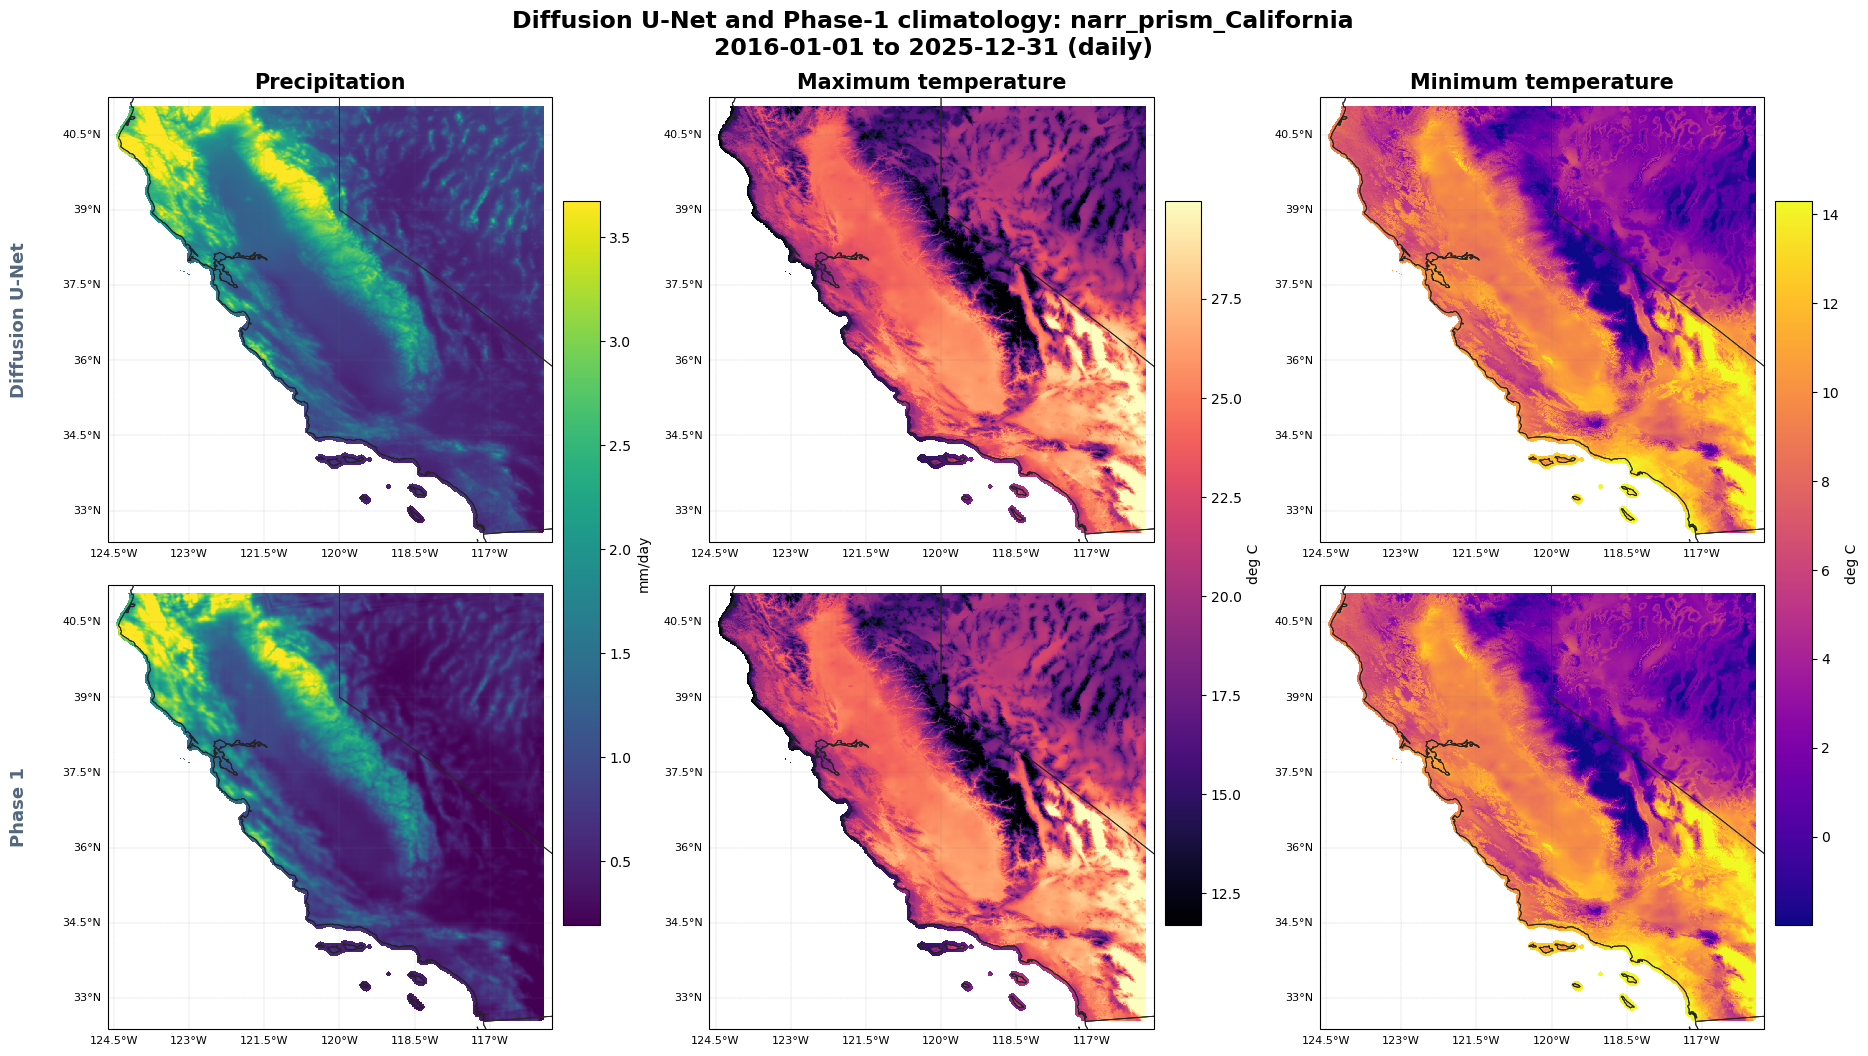

In [7]:
def plot_climatology_comparison():
    variables = [var for var in ("ppt", "tmax", "tmin") if var in target_variables]
    fig, axes = plt.subplots(
        2,
        len(variables),
        figsize=(6.2 * len(variables), 10.5),
        constrained_layout=True,
        subplot_kw=map_subplot_kw(),
        squeeze=False,
    )

    column_titles = {
        "ppt": "Precipitation",
        "tmax": "Maximum temperature",
        "tmin": "Minimum temperature",
    }
    row_fields = [("inference", "Diffusion U-Net"), ("phase1", "Phase 1")]

    for col, var in enumerate(variables):
        inf = climo[var]["inference"]
        baseline = climo[var]["phase1"]
        vmin, vmax = field_limits(inf, baseline)
        column_images = []

        for row, (field, row_label) in enumerate(row_fields):
            ax = axes[row, col]
            da = climo[var][field]
            im = da.plot(
                ax=ax,
                x="lon",
                y="lat",
                cmap=VAR_CMAPS.get(var, "viridis"),
                vmin=vmin,
                vmax=vmax,
                add_colorbar=False,
                **map_plot_kwargs(),
            )
            add_map_background(ax, da)
            ax.set_title(column_titles[var] if row == 0 else "", fontsize=15, fontweight="bold")
            column_images.append(im)

            if col == 0:
                ax.text(
                    -0.20,
                    0.5,
                    row_label,
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=13,
                    fontweight="bold",
                    color="#52677d",
                )

        cbar = fig.colorbar(column_images[0], ax=axes[:, col], shrink=0.76, pad=0.025)
        cbar.set_label(VAR_UNITS.get(var, ""))

    start = common_dates.min().strftime("%Y-%m-%d")
    end = common_dates.max().strftime("%Y-%m-%d")
    sampling = "daily" if CLIMO_DATE_STEP == 1 else f"every {CLIMO_DATE_STEP} days"
    fig.suptitle(
        f"Diffusion U-Net and Phase-1 climatology: {case_name}\n{start} to {end} ({sampling})",
        fontsize=17,
        fontweight="bold",
    )
    out = OUTPUT_DIR / f"{case_name}_diffusion_unet_vs_phase1_climatology_comparison.png"
    fig.savefig(out, dpi=180, bbox_inches="tight")
    print(out)
    return fig


if MAKE_CLIMATOLOGY:
    climatology_figure = plot_climatology_comparison()
    plt.show()
else:
    climatology_figure = None
    print("Skipped climatology plot.")

## Summary Metrics

The signed mean difference is refined minus Phase 1. The spatial mean RMS difference averages the per-pixel daily RMS differences; all statistics use the same paired finite-pixel mask.


In [8]:
if MAKE_CLIMATOLOGY:
    rows = []
    for var in target_variables:
        rows.append({
            "variable": var,
            "mean_refined": float(climo[var]["inference"].mean(skipna=True)),
            "mean_phase1": float(climo[var]["phase1"].mean(skipna=True)),
            "mean_refined_minus_phase1": float(climo[var]["difference"].mean(skipna=True)),
            "spatial_mean_rms_difference": float(climo[var]["rms_difference"].mean(skipna=True)),
            "valid_grid_cells": int((climo[var]["count"] > 0).sum()),
        })

    metrics = pd.DataFrame(rows)
    metrics_path = OUTPUT_DIR / f"{case_name}_diffusion_unet_vs_phase1_climatology_metrics.csv"
    metrics.to_csv(metrics_path, index=False)
    print(metrics_path)
    metrics
else:
    metrics = pd.DataFrame()
    metrics_path = None
    print("Skipped climatology metrics.")

metrics

/data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/diffusion_unet_vs_phase1/narr_prism_California_diffusion_unet_vs_phase1_climatology_metrics.csv


,variable,mean_refined,mean_phase1,mean_refined_minus_phase1,spatial_mean_rms_difference,valid_grid_cells
0,ppt,1.262100,0.983780,0.278320,0.571982,714742
1,tmax,21.072281,21.272373,-0.200093,0.561669,714742
2,tmin,6.337364,6.541266,-0.203902,0.590490,714742


## Maximum Temperature GIFs Over Los Angeles

Each frame shows the Diffusion U-Net refined ensemble mean, the matching Phase-1 inference, and **refined minus Phase 1**. Both fields share color limits. The notebook can create an LA County view and a tighter City of Los Angeles view.


In [9]:
def subset_to_bounds(da, bounds):
    lat_slice = slice(bounds["lat_min"], bounds["lat_max"])
    lon_slice = slice(bounds["lon_min"], bounds["lon_max"])
    if da.lat.values[0] > da.lat.values[-1]:
        lat_slice = slice(bounds["lat_max"], bounds["lat_min"])
    if da.lon.values[0] > da.lon.values[-1]:
        lon_slice = slice(bounds["lon_max"], bounds["lon_min"])

    subset = da.sel(lat=lat_slice, lon=lon_slice)
    if subset.sizes.get("lat", 0) == 0 or subset.sizes.get("lon", 0) == 0:
        raise ValueError(f"Animation bounds {bounds} do not overlap the data grid")
    return subset


def load_animation_frames(var, dates, bounds):
    frames = []
    for i, date in enumerate(dates, start=1):
        print(f"{var}: frame {i}/{len(dates)} {date.date()}")
        with open_inference_day(date, variables=[var]) as ds:
            inf = subset_to_bounds(ds[var].isel(time=0).astype("float32"), bounds)
            baseline = subset_to_bounds(ds[f"{var}_phase1"].isel(time=0).astype("float32"), bounds)
            valid = np.isfinite(inf) & np.isfinite(baseline)
            inf, baseline = inf.where(valid), baseline.where(valid)
            frames.append((date, inf, baseline, inf - baseline))
    return frames


def make_comparison_gif(var, dates, bounds, region_label, region_slug):
    frames = load_animation_frames(var, dates, bounds)
    if not frames:
        print(f"No frames for {var}")
        return None

    vmin, vmax = field_limits(*[item for _, inf, baseline, _ in frames for item in (inf, baseline)])
    diffs = [diff for _, _, _, diff in frames]
    dmin, dmax = symmetric_limits(xr.concat(diffs, dim="frame"))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), constrained_layout=True, subplot_kw=map_subplot_kw())
    titles = ["Diffusion U-Net", "Phase 1", "Diffusion U-Net - Phase 1"]
    cmaps = [VAR_CMAPS.get(var, "viridis"), VAR_CMAPS.get(var, "viridis"), "RdBu_r"]
    limits = [(vmin, vmax), (vmin, vmax), (dmin, dmax)]

    images = []
    _, first_inf, first_baseline, first_diff = frames[0]
    for ax, da, title, cmap, (lo, hi) in zip(axes, [first_inf, first_baseline, first_diff], titles, cmaps, limits):
        im = da.plot(ax=ax, x="lon", y="lat", cmap=cmap, vmin=lo, vmax=hi, add_colorbar=False, **map_plot_kwargs())
        add_map_background(
            ax,
            da,
            show_counties=ANIMATION_SHOW_COUNTIES,
            feature_scale=ANIMATION_FEATURE_SCALE,
            coastline_linewidth=ANIMATION_COASTLINE_LINEWIDTH,
            county_linewidth=ANIMATION_COUNTY_LINEWIDTH,
        )
        ax.set_title(title)
        images.append(im)

    # Diffusion U-Net and Phase 1 use identical limits and one shared colorbar.
    temperature_cbar = fig.colorbar(images[0], ax=axes[:2], shrink=0.82, pad=0.025)
    temperature_cbar.set_label(VAR_UNITS.get(var, ""))
    difference_cbar = fig.colorbar(images[2], ax=axes[2], shrink=0.82, pad=0.025)
    difference_cbar.set_label(VAR_UNITS.get(var, ""))

    suptitle = fig.suptitle("")

    def update(frame_idx):
        date, inf, baseline, diff = frames[frame_idx]
        for im, da in zip(images, [inf, baseline, diff]):
            im.set_array(np.asarray(da.values).ravel())
        suptitle.set_text(f"Maximum temperature over {region_label}: {date.strftime('%Y-%m-%d')}")
        return images + [suptitle]

    anim = FuncAnimation(fig, update, frames=len(frames), interval=1000 / GIF_FPS, blit=False)
    out = OUTPUT_DIR / f"{case_name}_diffusion_unet_vs_phase1_{var}_{region_slug}_{dates.min().strftime('%Y%m%d')}_{dates.max().strftime('%Y%m%d')}.gif"
    anim.save(out, writer=PillowWriter(fps=GIF_FPS))
    plt.close(fig)
    print(out)
    return out


if MAKE_GIFS:
    if GIF_VARIABLE != "tmax":
        raise ValueError("This animation is intentionally limited to Maximum temperature (tmax)")

    gif_specs = []
    if MAKE_LA_COUNTY_GIF:
        gif_specs.append(("LA County", "la_county", LA_COUNTY_BOUNDS, GIF_START, GIF_END))
    if MAKE_LA_CITY_GIF:
        gif_specs.append(("City of Los Angeles", "la_city", LA_CITY_BOUNDS, LA_CITY_GIF_START, LA_CITY_GIF_END))

    gif_paths = []
    for region_label, region_slug, bounds, start, end in gif_specs:
        gif_dates = existing_common_dates(start, end, variables=[GIF_VARIABLE])
        if len(gif_dates) == 0:
            raise FileNotFoundError(
                f"No paired refined/Phase-1 dates found for {region_label} GIF period {start} to {end}"
            )
        print(
            f"{region_label} GIF dates: {len(gif_dates)} "
            f"({gif_dates.min().date()} to {gif_dates.max().date()})"
        )
        gif_paths.append(
            make_comparison_gif(
                GIF_VARIABLE,
                gif_dates,
                bounds,
                region_label=region_label,
                region_slug=region_slug,
            )
        )
else:
    gif_paths = []

gif_paths

LA County GIF dates: 31 (2016-08-01 to 2016-08-31)
tmax: frame 1/31 2016-08-01
tmax: frame 2/31 2016-08-02
tmax: frame 3/31 2016-08-03
tmax: frame 4/31 2016-08-04
tmax: frame 5/31 2016-08-05
tmax: frame 6/31 2016-08-06
tmax: frame 7/31 2016-08-07
tmax: frame 8/31 2016-08-08
tmax: frame 9/31 2016-08-09
tmax: frame 10/31 2016-08-10
tmax: frame 11/31 2016-08-11
tmax: frame 12/31 2016-08-12
tmax: frame 13/31 2016-08-13
tmax: frame 14/31 2016-08-14
tmax: frame 15/31 2016-08-15
tmax: frame 16/31 2016-08-16
tmax: frame 17/31 2016-08-17
tmax: frame 18/31 2016-08-18
tmax: frame 19/31 2016-08-19
tmax: frame 20/31 2016-08-20
tmax: frame 21/31 2016-08-21
tmax: frame 22/31 2016-08-22
tmax: frame 23/31 2016-08-23
tmax: frame 24/31 2016-08-24
tmax: frame 25/31 2016-08-25
tmax: frame 26/31 2016-08-26
tmax: frame 27/31 2016-08-27
tmax: frame 28/31 2016-08-28
tmax: frame 29/31 2016-08-29
tmax: frame 30/31 2016-08-30
tmax: frame 31/31 2016-08-31
/data/granite-wxc/examples/NARR_PRISM/experiments/compariso

[PosixPath('/data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/diffusion_unet_vs_phase1/narr_prism_California_diffusion_unet_vs_phase1_tmax_la_county_20160801_20160831.gif'),
 PosixPath('/data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/diffusion_unet_vs_phase1/narr_prism_California_diffusion_unet_vs_phase1_tmax_la_city_20250701_20250731.gif')]